# Credit card fraud detection

## Introduction

The machine learning project aims to detect fraudulent credit card transaction, which is a growing problem for the banking industry and also for consumers. Due to growing scam and social engineering activities more people are victims. Therefore there are multiple stakeholders (regulatory authorities EBA & ECB, banks, consumers) interested in a sufficient fraud prevention and detection. 



This project considers the current developments in academic discussion and uses their approaches, mainly the recent published paper by "Shi et al (2025): An attention-based balanced variational autoencoder method for credit card fraud detection", on a different dataset which is publicly available on Hugging Face by the following link:

https://huggingface.co/datasets/pointe77/credit-card-transaction

The credit card data (most likely synthetic data) is downloaded from Hugging face, without providing any descriptions.
Nevertheless the used variables are quit obvious, by their structure and their content. 
So the qualitative data description will be conducted on industrial experience and best guesses.


In [2]:
# Importing standard packages
import polars as pl # Faster then pandas, 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # visualization
#import sklearn as 

from geopy.distance import distance #, geodesic, great_circle # Feature Engineering module for Geodata

In [3]:
# reading in the datasets
# Read CSV files with Polars
cc_train = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_train.csv")
cc_test  = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_test.csv")
# cc = pl.concat([cc_train, cc_test])
# del(cc_train, cc_test)

In [5]:
#"""
cc_train = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_train.csv")
cc_test  = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_test.csv")

cc_train = cc_train.with_columns(
    pl.col('trans_date_trans_time').str.to_datetime().alias('trans_date_trans_time')
)
cc_test = cc_test.with_columns(
    pl.col('trans_date_trans_time').str.to_datetime().alias('trans_date_trans_time')
)

train_min = cc_train['trans_date_trans_time'].min().date()
train_max = cc_train['trans_date_trans_time'].max().date()
test_min = cc_test['trans_date_trans_time'].min().date()
test_max = cc_test['trans_date_trans_time'].max().date()
#"""

In [ ]:
#train_min, train_max , test_min, test_max 

(datetime.date(2019, 1, 1),
 datetime.date(2020, 6, 21),
 datetime.date(2020, 6, 21),
 datetime.date(2020, 12, 31))

Threshold in noon (2020, 6, 21)

In [2]:
# reading in the datasets
# Read CSV files with Polars
cc = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_train.csv")
#cc_test  = pl.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_test.csv")
# cc = pl.concat([cc_train, cc_test])
# del(cc_train, cc_test)

# calculation for training, exporting
# then, copy of script, reading cc as cc_test. 
# seperate script/data import/ output fastest way (because of Outlier calc etc, not together and then split as consideration!) 

Additionally there is taken fraud data from the FBI fillings published via the pdf documentation.
State  data from the FBI.pdf, p.29
Losses per 100,000 citizens in each state

In [3]:
crime_data = pl.DataFrame({
    'State': ['District of Columbia', 'Nevada', 'California', 'New Jersey', 'Arizona', 
              'Alaska', 'Montana', 'South Dakota', 'Utah', 'Florida', 'New York', 
              'Washington', 'Hawaii', 'Maryland', 'Delaware', 'Minnesota', 'Massachusetts', 
              'Texas', 'Connecticut', 'Oregon', 'Kansas', 'Colorado', 'Virginia', 
              'Rhode Island', 'Pennsylvania', 'Georgia', 'Illinois', 'Idaho', 'Indiana', 
              'Wyoming', 'Tennessee', 'South Carolina', 'North Carolina', 'New Mexico', 
              'Nebraska', 'Michigan', 'Missouri', 'New Hampshire', 'Alabama', 'Iowa', 
              'North Dakota', 'Louisiana', 'Ohio', 'Oklahoma', 'Wisconsin', 'Arkansas', 
              'Puerto Rico', 'Vermont', 'Maine', 'West Virginia', 'Mississippi', 'Kentucky'],

    'State_ID': [ 'DC',    'NV',     'CA',     'NJ',     'AZ',
     'AK',     'MT',     'SD',     'UT',     'FL',     'NY',
     'WA',     'HI',     'MD',     'DE',     'MN',     'MA',
     'TX',     'CT',     'OR',     'KS',     'CO',     'VA',
     'RI',    'PA',     'GA',     'IL',     'ID',     'IN',
     'WY',     'TN',     'SC',     'NC',     'NM',     'NE',
     'MI',     'MO',     'NH',    'AL',     'IA',     'ND',
     'LA',     'OH', 'OK',     'WI',     'AR',     'PR',
     'VT',     'ME',     'WV',     'MS',     'KY'],
     
    'Loss in $/Capita': [6795914, 6292550, 5542009, 4748238, 4364657, 4332018, 4021353, 3900228,
             3869729, 3868631, 3831931, 3695066, 3603978, 3584328, 3428347, 3380137,
             3369186, 3348973, 3338719, 3213809, 3202070, 3192143, 3041335, 2882110,
             2779999, 2729130, 2675478, 2577030, 2364534, 2353556, 2261914, 2232240,
             2168543, 2134317, 2051237, 2026907, 1991645, 1938461, 1888622, 1865588,
             1726240, 1711639, 1674584, 1651948, 1557861, 1518551, 1479384, 1361957,
             1359051, 1211587, 1093451, 1076986]
})

Even though this specific dataset seems to be synthetically derived and the names and personal data is most likelly not critical to process, in the next steps there will be an anomisation of personel data for the following reasons:

- Depending on the contract between the bank and a third party consulting firm, the data might be depriaciated by the personal information. Therefore there is no simple deletion of the First and Last name of the data, but by an hashing algorithm an anomisation but still conserving client data informations of multiple credit cards. In reality it seems to be a realistic scenario that a victim loosing his credit card information, by social engineering or different scamming attacs might also loose multiple credit card information and therefore there might be a correlation with a causal background.

- The dataset contains also data for gender and date of birth, which is from an ethical viewpoint critical by a following discrimination. The results of the algorithm could suggest that a specific gender or age is more vulnerable to scam and therefore could be excluded from banking business or get an risk premium, by simply being in that socio economic group. In real application this should be considered.  

In [4]:
# hashing name data for anominization and deleting prior columns
cc = cc.with_columns(
    (pl.col("first").cast(pl.Utf8) + "|" + pl.col("last").cast(pl.Utf8)).alias("Owner_ID")
)

cc = cc.with_columns(
    pl.col("Owner_ID").hash().cast(pl.UInt64).alias("Owner_ID")
)

cc = cc.drop(['first', 'last']) 

## First Overview of the Data

### Qualitative Description of the DATA, What the Variables mean.



## Feature Engineering

Since some feature should be considered together, as input into the model are the engineered features instead of the original variables used.

Considering longitude and latitude in combination (both vor the victim, as well as for the merchant) results in information about the distance, whereas only each variable on their own is not sufficent.

Furthermore it is also reducing the dimensionality, by using less input variables within the model.

I.1) Engineered Feature 
Constructing a Risk Rating of each state by using FBI Data on Fraud occurence. If there are states in which due to governmental reasons, like regulation or technical infrasturcture. This feature might be an exogenous variable on our fraud flag. 

In [5]:
# combining States (governmental reasons) and their fraud losses/per Capita (extra dataset) as Risk-Rating Variable
# State_Risk_Rating

crime = crime_data.select([
    pl.col("State_ID"),
    pl.col("Loss in $/Capita").alias("State_Risk_Rating")
])

cc = cc.join(
    crime,
    left_on="state",
    right_on="State_ID",
    how="left"
)


I.2) Engineered Feature
Using the geolocation data, to check if the adress of the client/victim and the merchant is distant. It might indicate either travelling or online shopping, but also suspicous behaviour. An card usage abroad in south east asia, which did not happen before could be at least suspicous, contacting a client and asking for current travel could be a safety feature.


In [6]:
# Using client and merchant distance, rowwise
# from geopy.distance import distance 

cc = cc.with_columns(
    pl.struct(['lat', 'long', 'merch_lat', 'merch_long'])
    .map_elements(
        lambda row: distance((row['lat'], row['long']), 
                            (row['merch_lat'], row['merch_long'])).km,
        return_dtype=pl.Float64
    )
    .alias('dist_client_merchant')
)

I.3) Engineered Feature
This feature is measering the distance of the previous card transaction to the current card transaction in relation to time. Even though due to travel or online shopping, this information does not tell for sure any fraudulent behaviour, but it shows some unusual behaviour, which is at least an indicator. In comparison to the second feature it is a more complex, but also more causal.

In [7]:
# transforming str dtype int dateformat
cc = cc.with_columns(
    pl.col('trans_date_trans_time').str.to_datetime().alias('trans_date_trans_time')
)

In [8]:
# Using merchant distance and time between transactions for each card
cc = cc.sort(['cc_num', 'trans_date_trans_time'])

# Create lagged values for each card
cc = cc.with_columns([
    pl.col('merch_lat').shift(1).over('cc_num').alias('prev_merch_lat'),
    pl.col('merch_long').shift(1).over('cc_num').alias('prev_merch_long'),
    pl.col('trans_date_trans_time').shift(1).over('cc_num').alias('prev_trans_time')
])

# distance in km, per transaction
cc = cc.with_columns(
    pl.struct(['merch_lat', 'merch_long', 'prev_merch_lat', 'prev_merch_long'])
    .map_elements(
        lambda row: distance(
            (row['merch_lat'], row['merch_long']),
            (row['prev_merch_lat'], row['prev_merch_long'])
        ).km if row['prev_merch_lat'] is not None else 0.0, # None problem with lagged data
    ).alias('dist_prev_current_trans') # polars got a  problem with integer and Float64, therefore 0.0!
)


# transaction time difference
# maybe engineered feature on its own?
cc = cc.with_columns(
    pl.struct(['trans_date_trans_time', 'prev_trans_time'])
    .map_elements(
        lambda row: (row['trans_date_trans_time'] - row['prev_trans_time']).total_seconds()
        if row['prev_trans_time'] is not None else 0.0, # None problem with lagged data
    ).alias('trans_time_diff')
)


In [9]:

cc = cc.with_columns(
    (pl.col('dist_prev_current_trans') / pl.col('trans_time_diff'))
    .fill_nan(0.0)           #  0/0 case
    .replace(float('inf'), 0.0)  # division by trans_time_diff == 0
  #  .fill_null(0.0)          # Handle any remaining nulls
    .alias('travel_time_km')
)


# Unit Kilometers per second (km/s) (because more precise), per hour is unrealistic if 

In [ ]:
#cc.select('travel_time_km').head(100)

In [ ]:
#print(cc['category'].unique().to_list())

['travel', 'personal_care', 'entertainment', 'misc_pos', 'kids_pets', 'health_fitness', 'shopping_net', 'misc_net', 'gas_transport', 'grocery_pos', 'shopping_pos', 'food_dining', 'home', 'grocery_net']


In [10]:
# Therefore everything with *net is considered as online shopping, everything else physiscal bought via terminal
# (very easy assumption) unlikely in reality.
# But maybe Mastercard/Visa/Amex provide in reality data if card is used by a terminal / or via websecure..
# ['shopping_net','misc_net','grocery_net']
# Binary Variable for online shopping marker
cc = cc.with_columns(
    pl.when(pl.col('category').is_in(['shopping_net','misc_net','grocery_net']))
    .then(0)
    .otherwise(1)
    .alias('net_binary')
)

In [11]:
# checking what misc, means in this dataset
cc.filter(
    pl.col('category').is_in(['misc_net', 'misc'])
).select(['category', 'amt', 'merchant', 'is_fraud'])


category,amt,merchant,is_fraud
str,f64,str,i64
"""misc_net""",7.27,"""fraud_Jones, Sawayn and Romagu…",0
"""misc_net""",7.16,"""fraud_Herman, Treutel and Dick…",0
"""misc_net""",9.55,"""fraud_Huel Ltd""",0
"""misc_net""",189.17,"""fraud_Bogisich-Homenick""",0
"""misc_net""",5.23,"""fraud_Brown PLC""",0
…,…,…,…
"""misc_net""",400.25,"""fraud_Koelpin and Sons""",0
"""misc_net""",8.54,"""fraud_Moore, Dibbert and Koepp""",0
"""misc_net""",129.97,"""fraud_Kuphal-Predovic""",0


In [17]:
# checking the opposite:
cc.filter(
    ~pl.col('category').is_in(['misc_net', 'misc'])
).select(['category', 'amt', 'merchant', 'is_fraud'])


category,amt,merchant,is_fraud
str,f64,str,i64
"""gas_transport""",52.94,"""fraud_Berge LLC""",0
"""gas_transport""",82.08,"""fraud_Luettgen PLC""",0
"""kids_pets""",34.79,"""fraud_Daugherty LLC""",0
"""home""",27.18,"""fraud_Beier and Sons""",0
"""shopping_net""",6.87,"""fraud_Stamm-Witting""",0
…,…,…,…
"""personal_care""",60.47,"""fraud_Berge, Kautzer and Harri…",0
"""gas_transport""",74.29,"""fraud_Bernhard Inc""",0
"""shopping_net""",246.56,"""fraud_Reichert, Rowe and Mraz""",0


## Economists obsession with time related data...

If there is no strictly cross sectional data (which is not, in most cases), the question arises during the time span any structural changes are happening and if we are considering them appropriate. Since the training data spans the period, over 18 months (2019, 1, 1 until 2020, 6, 21) and the test data another 6 months (2020, 6, 21 until 2020, 12, 31) it might be a rather short period, but nevertheless a period in which enough could happen with explainable effects. 
Examples could be structural breaks due to new regulatory or technical advancements, which we don't now expicitly by observing the data for each US State. Another argument could be the start or end of a group or person with highly "motivated" scam activities.  

Transaction amount, more relevant then number of transactions!

correlation_cols = ['total_transactions',
 'total_amount', 'fraud_count']

# Calculate correlation matrix
correlation_matrix = weekly_stats[correlation_cols].corr()
print(correlation_matrix)

In [19]:
# Since we got labeled data we can check the Time Series of fraud activity (at least for this data, the reality might be different with unlabeled data):
cc = cc.with_columns([
    pl.col('trans_date_trans_time').dt.date().alias('trans_date'),
    pl.col('trans_date_trans_time').dt.week().alias('trans_week'),
    pl.col('trans_date_trans_time').dt.year().alias('trans_year'),
])

min_date = cc['trans_date'].min()

# weeks since start
cc = cc.with_columns(
    ((pl.col('trans_date') - min_date).dt.total_days() / 7).floor().cast(pl.Int32).alias('week_index')
)

# Aggregation weekly data
weekly_stats = cc.group_by(['week_index']).agg([
    pl.len().alias('total_transactions'),
    pl.col('is_fraud').sum().alias('fraud_count'),
    (pl.col('is_fraud').sum() / pl.len() * 100).alias('fraud_percentage')
]).sort(['week_index'])

Text(0.5, 1.0, 'Weekly Transactions vs Fraud Count')

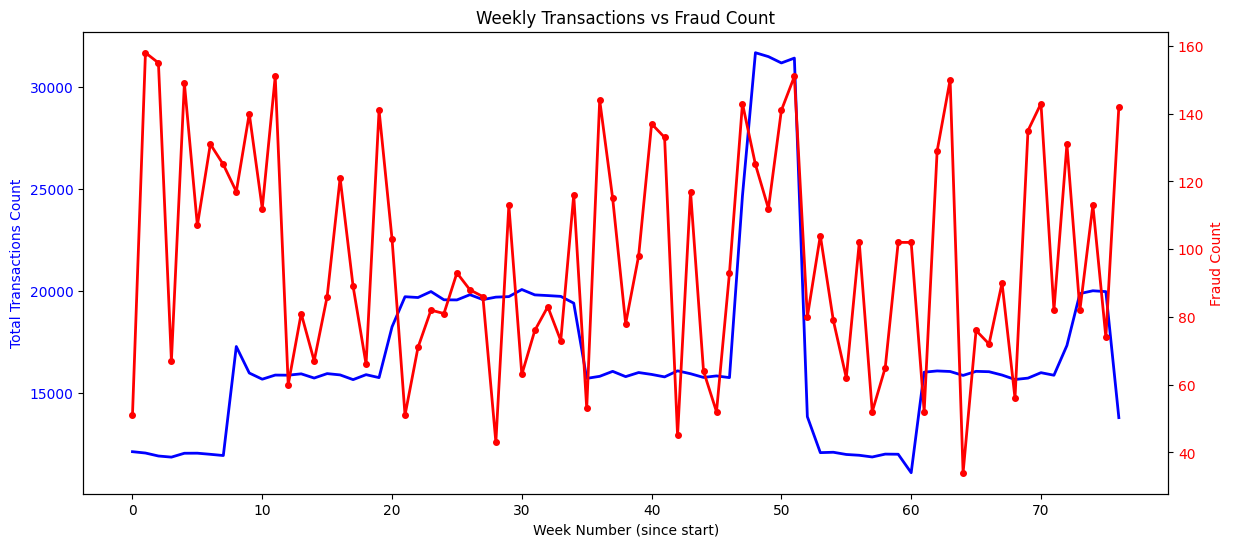

In [20]:
# Plot using week_index
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(weekly_stats['week_index'], weekly_stats['total_transactions'], 
         label='Total Transactions', color='blue', linewidth=2)
ax1.set_xlabel('Week Number (since start)')
ax1.set_ylabel('Total Transactions Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(weekly_stats['week_index'], weekly_stats['fraud_count'], 
         label='Fraud Count', color='red', linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Fraud Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Weekly Transactions vs Fraud Count')

Checking the Time Series visualy, the following seems to apply:
The fraud count seems to be stationary. Dickey Fuller Test can be conducted as addition.
The CC usage seems to get some seasonality, unfortunately the data does not cover multiple years (annualy seasonality seems to be dominating) and therefore it might be unsufficient to feature engineer. 
The rise of CC usage for christmas and then the low account balance afterwards is clearly visable. 

No strong trend (fraud isn't systematically increasing or decreasing)
No seasonality (no weekly, monthly, or quarterly patterns)
No memory effect (past fraud doesn't predict future fraud)

<Figure size 1000x400 with 0 Axes>

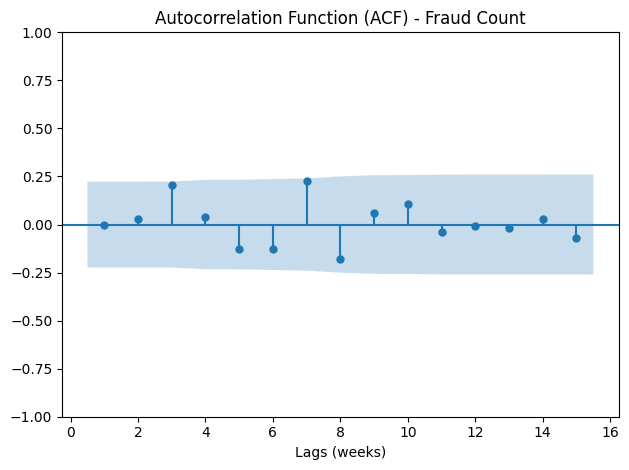

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
# Seasonality Autocorrelation Function (ACF)
plt.close('all')
plt.figure(figsize=(10, 4))
# Plot ACF 
plot_acf(weekly_stats['fraud_count'], lags=15, zero=False)
plt.title('Autocorrelation Function (ACF) - Fraud Count')
plt.xlabel('Lags (weeks)')
plt.tight_layout()
plt.show()


In [ ]:
# frequent card usage
# If a card is heavily used this might impact fraud. 
# A lot of transaction makes it harder to keep track of fraudulent transaction: 
# (1 Cent transfer, to check if cc data is valid, note: the min Transaction is a dollar, therefore no such feature)
# Calculation will be done daily / weekly. Not for the full period!
# Daily is from the perspective reasonable, because fraudulent transaction will most likely occur in a short time span
#  if scammers want to maximize their cc output. 
# weekly is on the other hand reasonable, because it is often (anglosaxian countries) that billing of utitilities/salary payment and also credit card invoices are sent on a weekly bases. 
# Therefore checks by the victims will most likely also occur in this time span

cc = cc.join(
    cc.group_by(['cc_num', 'trans_date']).agg(
        pl.count().alias('daily_transactions')
    ),
    on=['cc_num', 'trans_date'],
    how='left'
)

cc = cc.join(
    cc.group_by(['cc_num', 'trans_week']).agg(
        pl.count().alias('weekly_transactions')
    ),
    on=['cc_num', 'trans_week'],
    how='left'
)


In [12]:
# feature considering rural and metropolitan area (city population), but also the city name.
# frequent crime cities are important, but the population can be densed in the information.

# Village < 5.000 < 'Small_Town' < 50.000 < 'Town' < 500.000 < 'City' < 999.999 < 'Metropolitan_Area'  
# Numbers are debatable and choosen by personal estimation! (-> Here is a big attacking point)

cc = cc.with_columns(
    pl.when(pl.col('city_pop') < 5000)
    .then(pl.lit('Village'))
    .when(pl.col('city_pop') < 50000)
    .then(pl.lit('Small_Town'))
    .when(pl.col('city_pop') < 500000)
    .then(pl.lit('Town'))
    .when(pl.col('city_pop') < 1000000)
    .then(pl.lit('City'))
    .otherwise(pl.lit('Metropolitan_Area'))
    .alias('Population_Density')
)
# without pl.lit is an error... Check if time is left, about my package versions

# Histograms are usefull in considering the buckets graphical analysis of Raw Data. Is in a different part/other script. 
# To maintain some clean order and structure, because this script gets confusing...
"""
plt.hist(cc['city_pop'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('city_pop')
plt.ylabel('Frequency')
plt.title('City Population Distribution')
plt.show()
"""


"\nplt.hist(cc['city_pop'], bins=50, alpha=0.7, color='blue', edgecolor='black')\nplt.xlabel('city_pop')\nplt.ylabel('Frequency')\nplt.title('City Population Distribution')\nplt.show()\n"

In [19]:
cc['dob'].min(), cc['dob'].max()

('1924-10-30', '2005-01-29')

In [13]:
# changing type from string
cc = cc.with_columns(
    pl.col('dob').str.strptime(pl.Date, format="%Y-%m-%d")  # Adjust format as needed
)


In [14]:
# In similiar manner the variable Date of Birth is using a generational categorization
# Create generation variable
cc = cc.with_columns(
    pl.col('dob').dt.year().alias('birth_year')
).with_columns(
    pl.when(pl.col('birth_year') < 1946)
    .then(pl.lit('War_generation'))
    .when(pl.col('birth_year') < 1965)
    .then(pl.lit('Boomer'))
    .when(pl.col('birth_year') < 1981)
    .then(pl.lit('Gen X'))
    .when(pl.col('birth_year') < 1997)
    .then(pl.lit('Millennials'))
    .when(pl.col('birth_year') < 2013)
    .then(pl.lit('Gen Z'))
    .alias('generation')
).drop(['dob'])

# checking Birth year vs categorical in modelling

In [15]:
# Variable construction, Max amount per client in relation to IQR, but in avoidance to Multicollinearity,
# -> transformation in Outlier binary Variable. Flag unusual Spending Transaction.

cc = cc.with_columns(
    # Quantiles & maximum per credit card
    pl.col('amt').quantile(0.75).over('cc_num').alias('q3'),
    pl.col('amt').quantile(0.25).over('cc_num').alias('q1'),
).with_columns(
    ((pl.col('q3') - pl.col('q1')).alias('IQR')),
    ((pl.col('amt') / (pl.col('q3') - pl.col('q1'))).alias('amt_iqr_ratio'))
).with_columns(
    # binary outlier flag #Standard Value is 1.5, here 2.5
    (pl.col('amt') > pl.col('q3') + 2.5 * pl.col('IQR')).cast(pl.Int32).alias('Amount_Outlier_bin') 
).drop(['q3', 'q1', 'IQR'])  # Cleaning

# In modelling binary vs numeric ratio check!

In [23]:
# 2* IQR results in 59125 / 1793269 -> 0.032970513626232316 high as outlier flag
# 2.5  * IQR results in 48460 / 1803934 -> 0.026863510527547017 ...
print(cc['Amount_Outlier_bin'].value_counts())


shape: (2, 2)
┌────────────────────┬─────────┐
│ Amount_Outlier_bin ┆ count   │
│ ---                ┆ ---     │
│ i32                ┆ u32     │
╞════════════════════╪═════════╡
│ 1                  ┆ 34552   │
│ 0                  ┆ 1262123 │
└────────────────────┴─────────┘


In [16]:
# Combined Features 
# Time and Travel time for card usage relevant if no online shopping is happening!
cc = cc.with_columns(
    (pl.col('net_binary') * pl.col('travel_time_km')).alias('net_binary_comb_travel_time')
)
# Same dependency of online and transaction time
cc = cc.with_columns(
    (pl.col('net_binary') * pl.col('trans_time_diff')).alias('net_binary_comb_trans_time')
)

# Amount of spending relevant if it is an Outlier
cc = cc.with_columns(
    (pl.col('Amount_Outlier_bin') * pl.col('amt')).alias('Amount_Outlier_bin_comb_amt')
)



## ENCODING

II.1) Feature Representation
TODO: Adapt text to newer version
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

In [17]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
# import category_encoders as ce #worked with pandas

encoder_ORD = OrdinalEncoder() # category variable, with ordinal value the State Risk Rating etc...
cc = cc.with_columns(
    pl.Series(
        encoder_ORD.fit_transform(cc[['State_Risk_Rating']].to_numpy()).flatten()
    ).alias('State_Risk_Rating_labels')
)

# Encoder given with the order
encoder_ORD_pop = OrdinalEncoder(categories=[['Village','Small_Town','Town','City','Metropolitan_Area']])
# category variable, with ordinal value the State Risk Rating etc...

cc = cc.with_columns(
    pl.Series(
        encoder_ORD_pop.fit_transform(cc[['Population_Density']].to_numpy()).flatten()
    ).alias('Population_Density_labels')
)

encoder_ORD_gen = OrdinalEncoder(categories=[['War_generation','Boomer','Gen X','Millennials','Gen Z']])

cc = cc.with_columns(
    pl.Series(
        encoder_ORD_gen.fit_transform(cc[['generation']].to_numpy()).flatten()
    ).alias('generation_labels')
)

# No order between categories and each value own column....
encoder_gen_Hot = OneHotEncoder(drop='first', sparse_output=False)
cc = cc.with_columns(
    pl.Series(encoder_gen_Hot.fit_transform(cc[['gender']]).flatten()).alias('gender_label')
    )

# freq mapping
job_freq_map = cc['job'].value_counts().rename({'count': 'job_freq'})
category_freq_map = cc['category'].value_counts().rename({'count': 'category_freq'})
city_freq_map = cc['city'].value_counts().rename({'count': 'city_freq'})

cc = cc.join(job_freq_map, on='job', how='left')
cc = cc.join(category_freq_map, on='category', how='left')
cc = cc.join(city_freq_map, on='city', how='left')


In [18]:
# After Encoding:
# Same dependency of online and generational- Boomer and online shopping behaviour, fraud risk?
cc = cc.with_columns(
    (pl.col('generation_labels') * pl.col('net_binary')).alias('gen_label_comb_net_binary')
)

# Variable in combination of Job Frequency & Population Density 
# Assumption: less frequent jobs generally are better paid
# (because specialization and high number of educational years, with unpaid study years)
# Metropolitan area higher rent prices and correlation between higher salaries and higher lease prices.
# Attractive for fraud ("Dr." Credit Cards are sold achieving higher prices in the DarkNet)
cc = cc.with_columns(
    (pl.col('Population_Density_labels') * pl.col('job_freq')).alias('Pop_Dens_comb_job_freq')
)

# Population Density and Card usage in specififc Cities (freq) could be an indicator
# Less Cash payment offered for example, could also psycholagically lower the suspicous behaviour, 
# even if card reading terminal is not new and secured with updates.
cc = cc.with_columns(
    (pl.col('Population_Density_labels') * pl.col('city_freq')).alias('Pop_Dens_comb_city_freq')
)

"""
list comb:

'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt'
'gen_label_comb_net_binary', 'Pop_Dens_comb_job_freq', 'Pop_Dens_comb_city_freq'

"""

"\nlist comb:\n\n'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt'\n'gen_label_comb_net_binary', 'Pop_Dens_comb_job_freq', 'Pop_Dens_comb_city_freq'\n\n"

In [ ]:
print(job_freq_map)
print(category_freq_map)
print(city_freq_map)


shape: (494, 2)
┌─────────────────────────────────┬──────────┐
│ job                             ┆ job_freq │
│ ---                             ┆ ---      │
│ str                             ┆ u32      │
╞═════════════════════════════════╪══════════╡
│ IT trainer                      ┆ 7679     │
│ Equities trader                 ┆ 1549     │
│ Volunteer coordinator           ┆ 2024     │
│ Production assistant, televisi… ┆ 531      │
│ Doctor, hospital                ┆ 2554     │
│ …                               ┆ …        │
│ Chemist, analytical             ┆ 1012     │
│ Equality and diversity officer  ┆ 2572     │
│ Occupational psychologist       ┆ 4079     │
│ Chief Strategy Officer          ┆ 4603     │
│ Field seismologist              ┆ 1548     │
└─────────────────────────────────┴──────────┘
shape: (14, 2)
┌────────────────┬───────────────┐
│ category       ┆ category_freq │
│ ---            ┆ ---           │
│ str            ┆ u32           │
╞════════════════╪════════════

In [26]:
# double check if value is allright
print(f"'{'Architectural technologist'}' : {cc.filter(pl.col('job') == 'Architectural technologist').height}")

'Architectural technologist' : 1024


In [31]:
# cleaning variables which are unnecessary now (because of substitution of better engineered features)
# All string location variables: ['street','city','state','zip','lat','long','merch_zip','prev_merch_lat','prev_merch_long']
# Variables which are simply not used: ['unix_time', 'Unnamed','dob'] 
# -> for interpretation later, usefull: transformed variables ['gender','job','category','prev_trans_time','birth_year] # But exclusion from modelling step!
#del city_freq_map, category_freq_map, job_freq_map
cc_clean = cc.drop('street','city','state','zip','lat','long','merch_zipcode',
'prev_merch_lat','prev_merch_long','unix_time', 'Unnamed: 0')

In [32]:
## exporting as parquet for faster usage in future
#cc.write_parquet("credit_card_transactions.parquet")
# important test input and export change here!
cc_clean.write_parquet("credit_card_trans_train.parquet")
cc=cc_clean

In [8]:
# parquet reader
# cc=cc_clean
#del cc_clean
#del crime, crime_data, job_freq_map, city_freq_map, category_freq_map
import pandas as pd
cc = pl.read_parquet("credit_card_trans_train.parquet")
#cc = pd.read_parquet("credit_card_trans_train.parquet")

In [30]:
' Checking Values Descriptive Stats'

' Checking Values Descriptive Stats'

(Dornadula & Geetha, 2019): "Firstly, we use clustering method to divide the cardholders into different clusters/groups based on their transaction amount, i.e., high, medium and low using range partitioning.  Using Sliding-Window method, we aggregate the transactions into respective groups, i.e., extract some features from window to find cardholder's behavioural patterns. Features like maximum amount, minimum amount of transaction, followed by the average amount in the window and even the time elapsed."
/* features extraction related to amount */  ai1=MAX_AMT(Ti);  ai2=MIN_AMT(Ti);  ai3=AVG_AMT(Ti);  ai4=AMT(Ti);  For j in range i+w-1:  /* Time elapse */  xi= Time(tj)-Time(tj-1)  End  Xi= (ai1, ai2,ai3,ai4,ai5,);

In [27]:
def stat_values(df: pl.DataFrame, numeric_vars: list) -> pl.DataFrame:
    
    stats_list = []
    for col in numeric_vars: 
        stats = {
            "variable": col,
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "variance": df[col].var(),
            "min": df[col].min(),
            "q1": df[col].quantile(0.25),
            "q3": df[col].quantile(0.75),
            "max": df[col].max(),
            "range": df[col].max() - df[col].min(),
            "iqr": df[col].quantile(0.75) - df[col].quantile(0.25),
            "skewness": df[col].skew(),
            "kurtosis": df[col].kurtosis(),
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

# Usage
stats_df = stat_values(cc, ['amt','amt_iqr_ratio','State_Risk_Rating','dist_client_merchant','dist_prev_current_trans','trans_time_diff','travel_time_km'])
print(stats_df)

shape: (7, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ variable  ┆ mean      ┆ median    ┆ std       ┆ … ┆ range     ┆ iqr       ┆ skewness  ┆ kurtosis │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ amt       ┆ 70.351035 ┆ 47.52     ┆ 160.31603 ┆ … ┆ 28947.9   ┆ 73.49     ┆ 42.277825 ┆ 4545.627 │
│           ┆           ┆           ┆ 9         ┆   ┆           ┆           ┆           ┆ 447      │
│ amt_iqr_r ┆ 1.089604  ┆ 0.683161  ┆ 2.473006  ┆ … ┆ 438.23057 ┆ 1.209285  ┆ 39.007361 ┆ 4103.584 │
│ atio      ┆           ┆           ┆           ┆   ┆ 4         ┆           ┆           ┆ 458      │
│ State_Ris ┆ 2.7787e6  ┆ 2.72913e6 ┆ 1.1183e6  ┆ … ┆ 5.718928e ┆ 1.491515e 

In [ ]:
stats_comb= stat_values(cc, combined)


In [ ]:
stats_comb
# extreme outliers: log transform; net_binary_comb_travel_time, net_binary_comb_trans_time


variable,mean,median,std,variance,min,q1,q3,max,range,iqr,skewness,kurtosis
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""net_binary_comb_travel_time""",0.043934,0.003882,0.964531,0.93032,0.0,0.000976,0.012904,216.754079,216.754079,0.011928,107.239224,15619.215933
"""net_binary_comb_trans_time""",27434.992645,11703.0,45336.641512,2.0554e9,0.0,2227.0,33741.0,1.341471e6,1.341471e6,31514.0,4.458578,34.797808
"""Amount_Outlier_bin_comb_amt""",16.589008,0.0,156.735887,24566.138335,0.0,0.0,0.0,28948.9,28948.9,0.0,46.150745,5037.943997
"""gen_label_comb_net_binary""",1.746222,2.0,1.232014,1.517858,0.0,1.0,3.0,4.0,4.0,2.0,-0.068259,-1.131255
"""Pop_Dens_comb_job_freq""",2593.100852,0.0,4698.85093,2.2079e7,0.0,0.0,4095.0,36796.0,36796.0,4095.0,2.865033,11.55714
"""Pop_Dens_comb_city_freq""",1589.8952,0.0,3104.152626,9.6358e6,0.0,0.0,2058.0,20520.0,20520.0,2058.0,3.224345,13.019117


Amounts got extreme Outliers. In Basic Data.
Transformation (No 0 or negative Values makes it easier) -> log transformation.


In [24]:
def categorical_stats(df: pl.DataFrame, categorical_vars: list) -> pl.DataFrame:
    stats_list = []
    for col in categorical_vars:
        
        value_counts = df[col].value_counts()
                
        most_frequent = value_counts[0, col]
        most_freq_count = value_counts[0, "count"] 
        
        stats = {
            "variable": col,
            "n_unique": df[col].n_unique(),
            "most_frequent": most_frequent,
            "most_freq_pct": (most_freq_count / df.height) * 100,
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

cat_stats = categorical_stats(cc, ['category','gender','job','merchant','Population_Density'])


In [ ]:
cat_stats = categorical_stats(cc, combined)

In [26]:
cat_stats

variable,n_unique,most_frequent,most_freq_pct
str,i64,f64,f64
"""net_binary_comb_travel_time""",1089596,0.003568,0.000077
"""net_binary_comb_trans_time""",150440,12755.0,0.00162
"""Amount_Outlier_bin_comb_amt""",27618,691.79,0.000077
"""gen_label_comb_net_binary""",5,0.0,23.062448
"""Pop_Dens_comb_job_freq""",335,1048.0,0.040411
"""Pop_Dens_comb_city_freq""",267,2564.0,0.59321


II.1) Feature Representation
TODO:
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

## Lasso / Ridge Regression // LightGBM for preference feature check

Maybe Winsorization for some variables (extreme outliers....), therefore cutting them...

In [ ]:
# test data set and exclusion of y


In [41]:
# Before Preprocessing deciding which variables to transform
log_transf = ['amt','amt_iqr_ratio', 'dist_client_merchant','trans_time_diff','travel_time_km',
    'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt',
    'Pop_Dens_comb_job_freq', 'Pop_Dens_comb_city_freq'] # combined variables needs log transform as well 
## zero values are handled in log1p['trans_time_diff','travel_time_km']

# which to scale
scale =  [ 'dist_prev_current_trans', 'birth_year',
        'State_Risk_Rating_labels', 'generation_labels', 'city_freq','category_freq', 'gen_label_comb_net_binary'] # original labels not between 0 and 1

# which are left out
exception = ['net_binary','Amount_Outlier_bin','gender_label']

"""
combined= ['net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt',
'gen_label_comb_net_binary', 'Pop_Dens_comb_job_freq', 'Pop_Dens_comb_city_freq']
"""

"\ncombined= ['net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt',\n'gen_label_comb_net_binary', 'Pop_Dens_comb_job_freq', 'Pop_Dens_comb_city_freq']\n"

In [42]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# from polars to pandas conversion 

preprocessor = ColumnTransformer([
    # Log then scale
    ('log_then_scale', Pipeline([
        ('log', FunctionTransformer(np.log1p)),
        ('scale', StandardScaler())
    ]), log_transf),
    # only scaling
    ('scale_only', StandardScaler(), scale),
    # Pass through 
    ('pass_through', 'passthrough', exception)
])

# Create pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.0001))
])


In [ ]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_then_scale', ...), ('scale_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

X_transformed shape: (1296675, 14)
X_transformed type: <class 'numpy.ndarray'>
Lasso fit succeeded!


In [43]:
# from polars to pandas conversion 
X = cc[log_transf + scale + exception].to_pandas()
#X = cc[log_transf + scale + exception]
y = cc['is_fraud'].to_numpy()

In [56]:
# Fit and transform
pipeline.fit(X, y)

#predictions = pipeline.predict()

lasso_coefs = pipeline.named_steps['model'].coef_
feature_names = log_transf + scale + exception

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_coefs
}).sort_values('coefficient', key=lambda x: abs(x), ascending=False)
#features with 0 are out
print(coef_df.head(20))

                       feature  coefficient
3  Amount_Outlier_bin_comb_amt     0.022970
8                   net_binary    -0.007333
0              trans_time_diff    -0.004110
7                category_freq     0.003746
6                    city_freq    -0.003505
1               travel_time_km     0.003085
2  net_binary_comb_travel_time    -0.002833
5                   birth_year    -0.000579
4       Pop_Dens_comb_job_freq     0.000282


Second run, with only relevant Variables (shown greater then 0) and amt out, because better variable with outlier combination. 
['Amount_Outlier_bin_comb_amt', 'net_binary', 'trans_time_diff','category_freq','city_freq','travel_time_km','net_binary_comb_travel_time','birth_year','Pop_Dens_comb_job_freq']
                        feature  coefficient
7   Amount_Outlier_bin_comb_amt     0.022721
17                   net_binary    -0.007410
3               trans_time_diff    -0.004128
15                category_freq     0.003587
14                    city_freq    -0.003492
4                travel_time_km     0.003106
5   net_binary_comb_travel_time    -0.002852
0                           amt     0.000661
11                   birth_year    -0.000613
8        Pop_Dens_comb_job_freq     0.000290

In [44]:
# updating list
selection = ['Amount_Outlier_bin_comb_amt', 'net_binary', 'trans_time_diff',
                 'category_freq', 'city_freq', 'travel_time_km', 
                 'net_binary_comb_travel_time', 'birth_year', 'Pop_Dens_comb_job_freq']

# Updating my list
log_transf = [col for col in log_transf if col in selection]
scale =  [col for col in scale if col in selection]
exception = [col for col in exception if col in selection]

# check if same variable selection worked
check = set(log_transf + scale + exception) == set(['Amount_Outlier_bin_comb_amt', 'net_binary', 'trans_time_diff',
                 'category_freq', 'city_freq', 'travel_time_km', 
                 'net_binary_comb_travel_time', 'birth_year', 'Pop_Dens_comb_job_freq'])

check

True

In [ ]:
import lightgbm as lgb
# pipeline with LightGBM (Non Linear relationships)
pipeline_feature_check = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced'
    ))
])

In [ ]:
# running again
pipeline.fit(X, y)
# again printing the results
#predictions = pipeline.predict()

feature_importance = pipeline_feature_check.named_steps['model'].feature_importances_
feature_names = log_transf + scale + exception

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1606
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

| Rank | Feature | Importance Score |
|:----:|---------|----------------:|
| 1 | `category_freq` | 575 |
| 2 | `trans_time_diff` | 495 |
| 3 | `city_freq` | 444 |
| 4 | `Amount_Outlier_bin_comb_amt` | 430 |
| 5 | `birth_year` | 354 |
| 6 | `Pop_Dens_comb_job_freq` | 243 |
| 7 | `net_binary_comb_travel_time` | 153 |
| 8 | `travel_time_km` | 108 |
| 9 | `net_binary` | 30 |

### Lasso Feature Ranking (Linear patterns)

| Rank | Feature | Coefficient |
|:----:|---------|------------:|
| 1 | `Amount_Outlier_bin_comb_amt` | +0.0227 |
| 2 | `net_binary` | -0.0074 |
| 3 | `trans_time_diff` | -0.0041 |
| 4 | `category_freq` | +0.0036 |
| 5 | `city_freq` | -0.0035 |
| 6 | `travel_time_km` | +0.0031 |
| 7 | `net_binary_comb_travel_time` | -0.0029 |
| 8 | `amt` | +0.0007 |
| 9 | `birth_year` | -0.0006 |
| 10 | `Pop_Dens_comb_job_freq` | +0.0003 |


In [ ]:
# same code run as copy with test data as cc
# Therefore here already in same structure with enigineered features.
cc_test = pl.read_parquet("credit_card_trans_test.parquet")


In [39]:
X_test = cc_test[log_transf + scale + exception].to_numpy()  
y_test = cc_test['is_fraud'].to_numpy()

Mentioned models for CC Fraud Detection in 

Dornadula, V. N., & Geetha, S. (2019). Credit Card Fraud Detection using Machine Learning Algorithms. Procedia Computer Science, 165, 631–641. https://doi.org/10.1016/j.procs.2020.01.057

XGBoost, KNN, SVM.

Decision to use XGBoost & LinearSVM (instead of KNN), because of more dimensionalities and also faster calculation.

Also in:
(Tiwari et al., 2021, p. 4):"Support Vector Machines  Support vector machines or SVMs are linear classifiers as stated in [5] that work in high dimensionality because in high-dimensions, a non-linear task in input becomes linear and hence this makes SVMs highly useful for detecting frauds. Due to its two most important features that is a kernel function to represent classification function in the dot product of input data point projection, and the fact that it tries finding a hyperplane to maximize separation between classes while minimizing overfitting of training data, it provides a very high generalization capability."

In [45]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

In [ ]:
## XGBoost as Model
pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [47]:
pipeline_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_then_scale', ...), ('scale_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [48]:
hiperparam_distributions = {
    'classifier__n_estimators': randint(50, 300),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth
    'classifier__learning_rate': uniform(0.01, 0.3),        # Step size shrinkage
    'classifier__subsample': uniform(0.6, 0.4),             # Row sampling
    'classifier__colsample_bytree': uniform(0.6, 0.4),      # Column sampling
    'classifier__min_child_weight': randint(1, 10),         # Min instances in leaf
    'classifier__gamma': uniform(0, 0.5),                   # Min loss reduction
    'classifier__reg_alpha': uniform(0, 1),                 # L1 regularization
    'classifier__reg_lambda': uniform(0.5, 1.5)             # L2 regularization
}

In [51]:
randomized_search_xgb = RandomizedSearchCV(
    pipeline_xgboost,
    hiperparam_distributions,
    n_iter=10,
    cv=5,
    scoring='roc_auc',                 
    random_state=42,
    n_jobs=-1,                         
    verbose=1 
)


In [52]:
randomized_search_xgb.fit(X, y)
print("Best params:", randomized_search_xgb.best_params_)
print("Best score:", randomized_search_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sarima/anaconda3/envs/mkl_optimized/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encode

Best params: {'classifier__colsample_bytree': np.float64(0.902144564127061), 'classifier__gamma': np.float64(0.21257793724562235), 'classifier__learning_rate': np.float64(0.07238249886045664), 'classifier__max_depth': 6, 'classifier__min_child_weight': 6, 'classifier__n_estimators': 270, 'classifier__reg_alpha': np.float64(0.9695846277645586), 'classifier__reg_lambda': np.float64(1.6626992350416718), 'classifier__subsample': np.float64(0.9757995766256756)}
Best score: 0.9964869102762874


In [55]:
# Show top 5 parameter combinations
results = pd.DataFrame(randomized_search_xgb.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
top5

,params,mean_test_score,std_test_score
6,{'classifier__colsample_bytree': 0.90214456412...,0.996487,0.000606
3,{'classifier__colsample_bytree': 0.98950220753...,0.996114,0.000839
4,{'classifier__colsample_bytree': 0.84301794076...,0.993321,0.001317
2,{'classifier__colsample_bytree': 0.67336180394...,0.993002,0.000892
5,{'classifier__colsample_bytree': 0.69235753024...,0.992418,0.001732


In [53]:
best_xgboost = randomized_search_xgb.best_estimator_

Concept of Voting Classifier.
Lasso Regression, LightGBM -> Feature Selection
Since the  XGBoost, LSVC as Model -> Voting if 


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Create voting ensemble # Two models predict and prediction together is used.
ensemble = VotingClassifier(
    estimators=     
        ('lgb', pipeline_LSVC), 
        ('xgb', pipeline_xgb)
    ],
    voting='soft',
    weights=[1, 1]  # Equal weight
)

# Train
ensemble.fit(X, y)

# Compare with individual models
models = {
    'LightGBM': pipeline_LSVC,
    'XGBoost': pipeline_xgb,
    'Ensemble': ensemble
}

for name, model in models.items():
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_proba)

# Analyis

In qualitative variable analysis, the
- construction of our Amount Outlier might be discussed. (Values 1.5, 2, 2.5 etc * IQR in threshold)  
- City Population might be differently calculated, by choosing different ranges or more/less categories...
- generational variable